In [ ]:
import numpy as np
import pandas as pd

destinations = {
    "Pulau Redang": {
        "coral_cover": 0.2589,
        "nrw": 0.420,
        "water_mld": 173.0,
        "visitor_demand": 15.46,       # millions
        "acceptable_demand": 10.0,      # millions
    },
    "Cameron Highlands": {
        "coral_cover": np.nan,
        "nrw": 0.485,
        "water_mld": 283.0,
        "visitor_demand": 23.754,       # thousands
        "acceptable_demand": 15.0,      # thousands
    },
    "George Town": {
        "coral_cover": np.nan,
        "nrw": 0.284,
        "water_mld": 334.0,
        "visitor_demand": 23.544,       # thousands
        "acceptable_demand": 20.0,      # thousands
    },
    "Tunku Abdul Rahman Park": {
        "coral_cover": 0.1313,
        "nrw": 0.596,
        "water_mld": 238.0,
        "visitor_demand": 0.54638,      # millions (546.38k)
        "acceptable_demand": 0.5,       # millions
    },
}

df = pd.DataFrame(destinations).T

# Coral cover (higher is better, inverted)
coral_min, coral_max = 0.10, 0.50
df["S_coral"] = (coral_max - df["coral_cover"]) / (coral_max - coral_min)
df["S_coral"] = df["S_coral"].fillna(0.5)  # neutral for inland

# NRW (higher is worse)
nrw_min, nrw_max = 0.20, 0.65
df["S_nrw"] = (df["nrw"] - nrw_min) / (nrw_max - nrw_min)

# Water consumption (higher is worse)
water_min, water_max = 100, 400
df["S_water"] = (df["water_mld"] - water_min) / (water_max - water_min)

# Demand stress ratio (visitor / acceptable)
df["S_demand"] = df["visitor_demand"] / df["acceptable_demand"]
df["S_demand"] = df["S_demand"] / df["S_demand"].max()  # normalize to 0-1

# Weights
w_biophysical = 0.291
w_planning = 0.250
w_facilities = 0.229
w_socio = 0.230

df["Capacity_Index"] = (
    w_biophysical * df["S_coral"]
    + w_planning * df["S_nrw"]
    + w_facilities * df["S_water"]
    + w_socio * df["S_demand"]
)

def assign_status(idx):
    if idx < 0.55:
        return "Green"
    elif idx <= 0.70:
        return "Yellow"
    else:
        return "Red"

df["Status"] = df["Capacity_Index"].apply(assign_status)

print(df[["coral_cover", "nrw", "water_mld", "Capacity_Index", "Status"]].to_string())

                         coral_cover    nrw  water_mld  Capacity_Index  Status
Pulau Redang                  0.2589  0.420      173.0        0.577885  Yellow
Cameron Highlands                NaN  0.485      283.0        0.673523  Yellow
George Town                      NaN  0.284      334.0        0.541762   Green
Tunku Abdul Rahman Park       0.1313  0.596      238.0        0.752280     Red


In [2]:
from google.colab import files
uploaded = files.upload()


Saving tourism data.xlsx to tourism data (1).xlsx


In [3]:
!pip install openpyxl -q

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler

FILE = "tourism data.xlsx"
xls = pd.ExcelFile(FILE)

def clean_state(s):
    if pd.isna(s): return s
    s = str(s).strip().upper()
    s = s.replace("W.P.", "WP").replace("W.P", "WP")
    s = s.replace(".", "").replace("  ", " ")
    return s.strip()

sheet1 = pd.read_excel(FILE, sheet_name="Sheet1")
sheet1 = sheet1.rename(columns={sheet1.columns[0]: "STATE"})
sheet1["STATE"] = sheet1["STATE"].apply(clean_state)
sheet1 = sheet1[sheet1["STATE"].notna()]
sheet1 = sheet1[~sheet1["STATE"].astype(str).str.contains("AVERAGE", case=False, na=False)]

sheet3 = pd.read_excel(FILE, sheet_name="2024")
sheet3 = sheet3.rename(columns={sheet3.columns[0]: "STATE"})
sheet3["STATE"] = sheet3["STATE"].apply(clean_state)
sheet3 = sheet3[sheet3["STATE"].notna()]

sheet4 = pd.read_excel(FILE, sheet_name="HOTEL GUEST BY STATE ")
sheet4 = sheet4.rename(columns={sheet4.columns[0]: "STATE"})
sheet4["STATE"] = sheet4["STATE"].apply(clean_state)
sheet4 = sheet4[sheet4["STATE"].notna()]
sheet4 = sheet4.rename(columns={"DOMESTIC": "DOMESTIC_2025", "INTERNATIONAL": "INTERNATIONAL_2025"})

sheet5 = pd.read_excel(FILE, sheet_name="STATE POPULATION 2025")
sheet5 = sheet5.rename(columns={sheet5.columns[0]: "STATE"})
sheet5["STATE"] = sheet5["STATE"].apply(clean_state)
sheet5 = sheet5[sheet5["STATE"].notna()]
sheet5 = sheet5[["STATE", "population,000", "TOURISM PRESSURE RATIO"]]
sheet5 = sheet5.rename(columns={"population,000": "POPULATION_2025",
                                "TOURISM PRESSURE RATIO": "TOURISM_PRESSURE_2025"})

sheet6 = pd.read_excel(FILE, sheet_name="GDP_2025")
sheet6 = sheet6.rename(columns={sheet6.columns[1]: "STATE", sheet6.columns[2]: "GDP_2025"})
sheet6["STATE"] = sheet6["STATE"].apply(clean_state)
sheet6 = sheet6[sheet6["STATE"].notna()]
sheet6 = sheet6[["STATE", "GDP_2025"]]

df = sheet1.merge(sheet3, on="STATE", how="left", suffixes=("", "_2024"))
df = df.merge(sheet4, on="STATE", how="left")
df = df.merge(sheet5, on="STATE", how="left")
df = df.merge(sheet6, on="STATE", how="left")

if "HOTEL ROOM_2024" in df.columns:
    df = df.drop(columns=["HOTEL ROOM_2024"])
formula_cols = [c for c in df.columns if str(c).startswith(("CI", "CCI", "C P", "CP"))]
df = df.drop(columns=formula_cols, errors="ignore")

numeric_df = df.select_dtypes(include=[np.number]).copy()
numeric_df["STATE"] = df["STATE"].values
numeric_df = numeric_df.fillna(numeric_df.median(numeric_only=True))
numeric_df = numeric_df.dropna(axis=1, how="all")

print("Numeric columns:")
print(numeric_df.columns.tolist())
print("\nNA counts:")
print(numeric_df.isna().sum())
print("\nFirst 5 rows:")
print(numeric_df.head())

Numeric columns:
['2025_x', 2026, 2027, 2028, 'HOTEL ROOM', 'AOR(%)', 'Holidays Homes', 'Capacity Limit', 'No relatives & friends house (%)', 'NRW(%)', 'Coral Pressure(5)', 'Waste Treatment Presure', 'Environment Pressure', 'population', 'community pressure 2026', 'TOURISM RECEIPTS', 'HOTEL/GUEST ACCOMMODATION', 'NUMBER OF TRIP', 'NUM OF HOTEL', 'POPULATION_2025', 'TOURISM_PRESSURE_2025', 'GDP_2025', 'STATE']

NA counts:
2025_x                              0
2026                                0
2027                                0
2028                                0
HOTEL ROOM                          0
AOR(%)                              0
Holidays Homes                      0
Capacity Limit                      0
No relatives & friends house (%)    0
NRW(%)                              0
Coral Pressure(5)                   0
Waste Treatment Presure             0
Environment Pressure                0
population                          0
community pressure 2026             0
TOURI

Number of features: 23
Number of states: 16


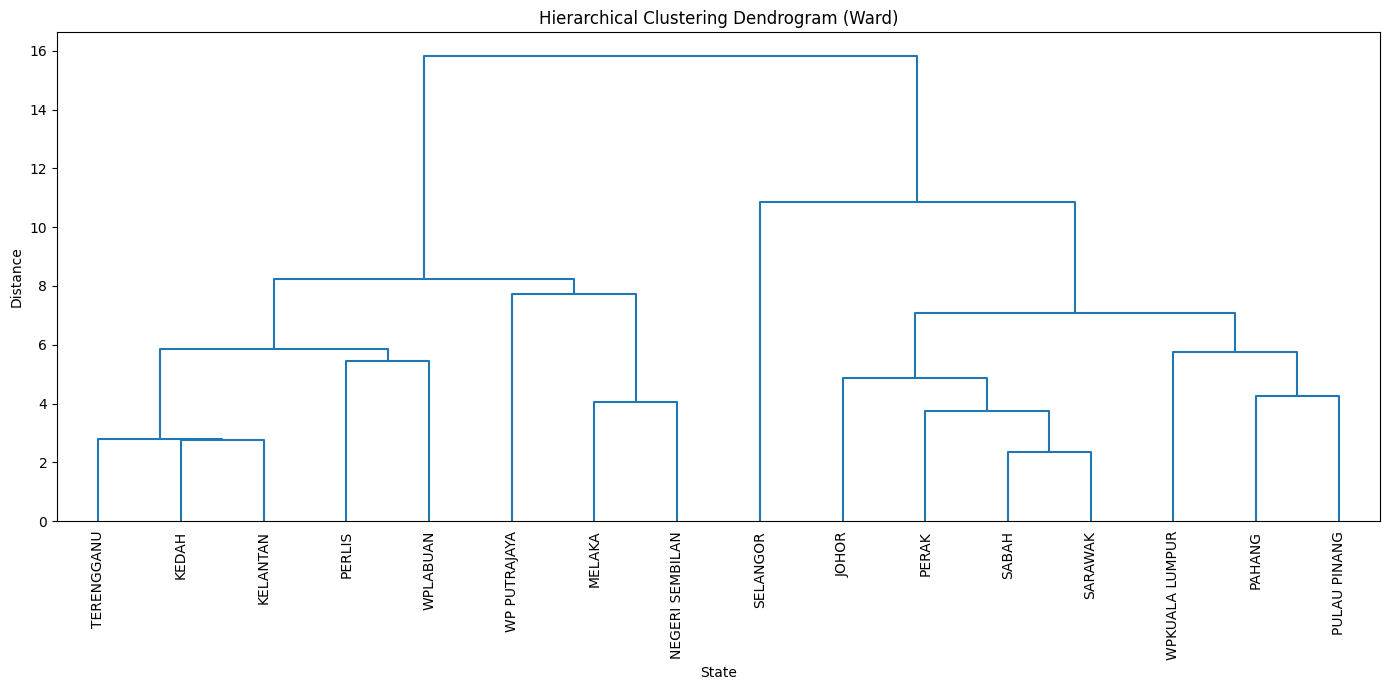


=== Cluster Results ===
          STATE  Cluster
       KELANTAN        1
          KEDAH        1
NEGERI SEMBILAN        1
         MELAKA        1
   WP PUTRAJAYA        1
       WPLABUAN        1
     TERENGGANU        1
         PERLIS        1
          SABAH        2
   PULAU PINANG        2
          JOHOR        2
         PAHANG        2
 WPKUALA LUMPUR        2
          PERAK        2
        SARAWAK        2
       SELANGOR        3


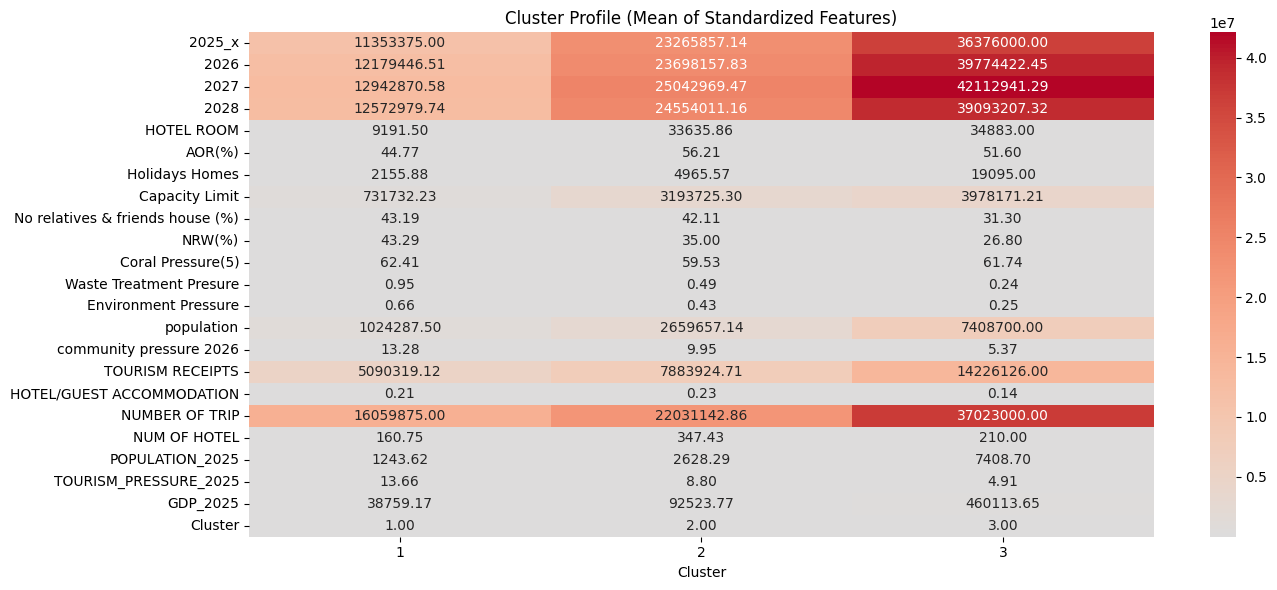


=== Cluster Names ===
          STATE  Cluster       ClusterName
       KELANTAN        1     High Pressure
          KEDAH        1     High Pressure
NEGERI SEMBILAN        1     High Pressure
         MELAKA        1     High Pressure
   WP PUTRAJAYA        1     High Pressure
       WPLABUAN        1     High Pressure
     TERENGGANU        1     High Pressure
         PERLIS        1     High Pressure
          SABAH        2 Moderate Pressure
   PULAU PINANG        2 Moderate Pressure
          JOHOR        2 Moderate Pressure
         PAHANG        2 Moderate Pressure
 WPKUALA LUMPUR        2 Moderate Pressure
          PERAK        2 Moderate Pressure
        SARAWAK        2 Moderate Pressure
       SELANGOR        3      Low Pressure


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


[DONE]


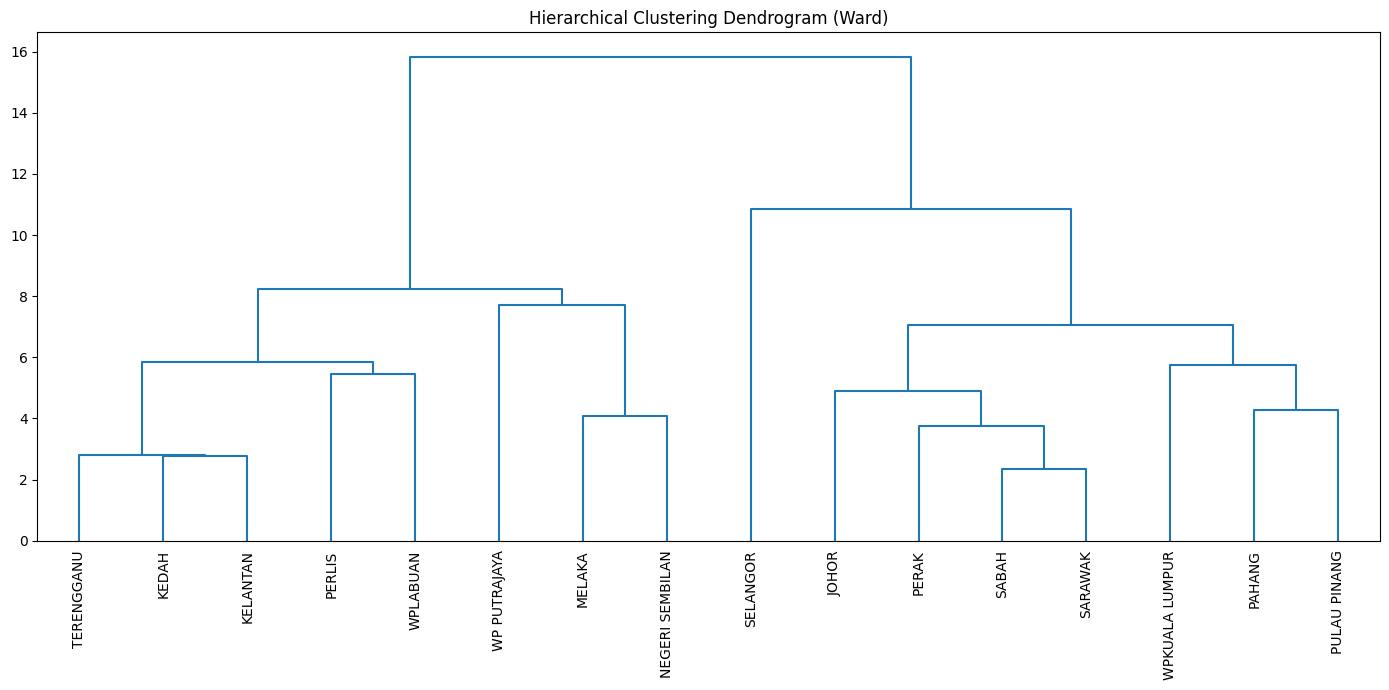

In [9]:
numeric_df.columns = numeric_df.columns.astype(str)

features = numeric_df.drop(columns=["STATE"])
X_scaled = StandardScaler().fit_transform(features)

print("Number of features:", features.shape[1])
print("Number of states:", features.shape[0])

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(14, 7))
dendrogram(
    Z,
    labels=numeric_df["STATE"].values,
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=0
)
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("State")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

N_CLUSTERS = 3
numeric_df["Cluster"] = fcluster(Z, t=N_CLUSTERS, criterion="maxclust")

print("\n=== Cluster Results ===")
print(numeric_df[["STATE", "Cluster"]].sort_values("Cluster").to_string(index=False))

import seaborn as sns
cluster_profile = numeric_df.groupby("Cluster")[features.columns].mean()

plt.figure(figsize=(14, 6))
sns.heatmap(
    cluster_profile.T,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Cluster Profile (Mean of Standardized Features)")
plt.tight_layout()
plt.show()

pressure_by_cluster = numeric_df.groupby("Cluster")["TOURISM_PRESSURE_2025"].mean()
sorted_clusters = pressure_by_cluster.sort_values().index.tolist()

name_map = {
    sorted_clusters[0]: "Low Pressure",
    sorted_clusters[1]: "Moderate Pressure",
    sorted_clusters[2]: "High Pressure"
}

numeric_df["ClusterName"] = numeric_df["Cluster"].map(name_map)

print("\n=== Cluster Names ===")
print(numeric_df[["STATE", "Cluster", "ClusterName"]]
      .sort_values("Cluster")
      .to_string(index=False))

numeric_df.to_csv("clustering_result.csv", index=False)

plt.figure(figsize=(14, 7))
dendrogram(
    Z,
    labels=numeric_df["STATE"].values,
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=0
)
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.tight_layout()
plt.savefig("dendrogram.png", dpi=150)

from google.colab import files
files.download("clustering_result.csv")
files.download("dendrogram.png")

print("\n[DONE]")

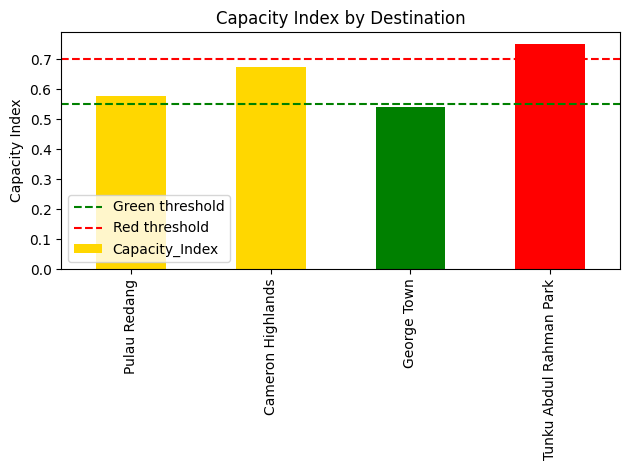

In [ ]:
import matplotlib.pyplot as plt

df["Capacity_Index"].plot(kind="bar", color=["gold", "gold", "green", "red"])
plt.title("Capacity Index by Destination")
plt.ylabel("Capacity Index")
plt.axhline(y=0.55, color="green", linestyle="--", label="Green threshold")
plt.axhline(y=0.70, color="red", linestyle="--", label="Red threshold")
plt.legend()
plt.tight_layout()
plt.show()

CAPACITY INDEX RESULTS — MALAYSIA TOURISM DESTINATIONS
                         coral_cover    nrw  water_mld  Capacity_Index  Status
Pulau Redang                  0.2589  0.420      173.0        0.458998   Green
Cameron Highlands                NaN  0.485      283.0        0.576003  Yellow
George Town                      NaN  0.284      334.0        0.481327   Green
Tunku Abdul Rahman Park       0.1313  0.596      238.0        0.771041     Red


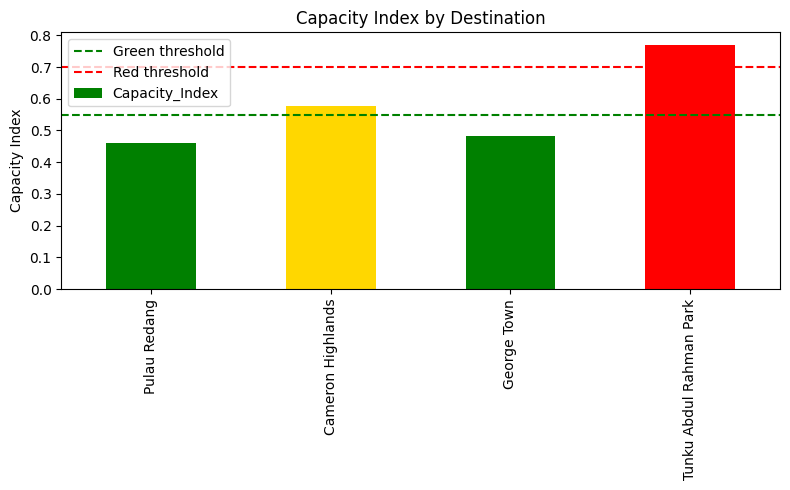

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# STEP 1: Define Destinations and Raw Indicators
# ============================================================

destinations = {
    "Pulau Redang": {
        "coral_cover": 0.2589,
        "nrw": 0.420,
        "water_mld": 173.0,
        "capacity_demand_ratio": 0.85,
    },
    "Cameron Highlands": {
        "coral_cover": np.nan,
        "nrw": 0.485,
        "water_mld": 283.0,
        "capacity_demand_ratio": 0.92,
    },
    "George Town": {
        "coral_cover": np.nan,
        "nrw": 0.284,
        "water_mld": 334.0,
        "capacity_demand_ratio": 0.78,
    },
    "Tunku Abdul Rahman Park": {
        "coral_cover": 0.1313,
        "nrw": 0.596,
        "water_mld": 238.0,
        "capacity_demand_ratio": 0.88,
    },
}

df = pd.DataFrame(destinations).T

# ============================================================
# STEP 2: Normalize Indicators (0–1 scale)
# ============================================================

# --- Coral cover (higher is better → invert) ---
coral_min, coral_max = 0.10, 0.50
df["S_coral"] = (coral_max - df["coral_cover"]) / (coral_max - coral_min)
df["S_coral"] = df["S_coral"].fillna(0.5)  # neutral for inland destinations

# --- NRW (higher is worse) ---
nrw_min, nrw_max = 0.20, 0.65
df["S_nrw"] = (df["nrw"] - nrw_min) / (nrw_max - nrw_min)

# --- Water consumption (higher is worse) ---
water_min, water_max = 100, 400
df["S_water"] = (df["water_mld"] - water_min) / (water_max - water_min)

# --- Demand ratio (higher is worse) ---
df["S_demand"] = df["capacity_demand_ratio"]

# ============================================================
# STEP 3: Apply Redistributed AHP Weights (Sum = 1.0)
# ============================================================
# Original Perhentian study weights:
#   Biophysical = 0.291
#   Planning    = 0.250
#   Facilities  = 0.229
#   Subtotal    = 0.770
#
# Redistributed proportionally to sum to 1.0:
#   Biophysical = 0.291 / 0.770 = 0.378
#   Planning    = 0.250 / 0.770 = 0.325
#   Facilities  = 0.229 / 0.770 = 0.297
#   Total       = 1.000

w_biophysical = 0.378
w_planning = 0.325
w_facilities = 0.297

df["Capacity_Index"] = (
    w_biophysical * df["S_coral"]
    + w_planning * df["S_nrw"]
    + w_facilities * df["S_water"]
)

# ============================================================
# STEP 4: Assign Status (Green / Yellow / Red)
# ============================================================

def assign_status(idx):
    if idx < 0.55:
        return "Green"
    elif idx <= 0.70:
        return "Yellow"
    else:
        return "Red"

df["Status"] = df["Capacity_Index"].apply(assign_status)

# ============================================================
# STEP 5: Print Results
# ============================================================

print("=" * 70)
print("CAPACITY INDEX RESULTS — MALAYSIA TOURISM DESTINATIONS")
print("=" * 70)
print(
    df[
        ["coral_cover", "nrw", "water_mld", "Capacity_Index", "Status"]
    ].to_string()
)
print("=" * 70)

# ============================================================
# STEP 6: Visualize Results
# ============================================================

colors = df["Status"].map({"Green": "green", "Yellow": "gold", "Red": "red"})

df["Capacity_Index"].plot(kind="bar", color=colors, figsize=(8, 5))
plt.title("Capacity Index by Destination")
plt.ylabel("Capacity Index")
plt.axhline(y=0.55, color="green", linestyle="--", label="Green threshold")
plt.axhline(y=0.70, color="red", linestyle="--", label="Red threshold")
plt.legend()
plt.tight_layout()
plt.show()